# MÔ HÌNH HỒI QUY (REGRESSION) - DỰ ĐOÁN CALORIES & THỰC NGHIỆM ABLATION STUDY

**Mục tiêu:** Xây dựng mô hình Hồi quy dự báo lượng `calories` tiêu thụ. Thay vì chỉ huấn luyện một mạch, Notebook này áp dụng phương pháp **Nghiên cứu cắt lớp (Ablation Study)** để chứng minh tầm quan trọng của việc xử lý dữ liệu ngoại lai (Outliers) đối với các thuật toán Hồi quy.

## Mục lục
1. [Khởi tạo Hệ thống & Chặn rò rỉ dữ liệu (Target Leakage)](#b1)
2. [Kịch bản A - Đánh giá Baseline trên Dữ liệu Gốc (Có nhiễu)](#b2)
3. [Kịch bản B - Xử lý nhiễu bằng Tứ phân vị (IQR) & Đánh giá lại](#b3)
4. [ Kịch bản C - Tinh chỉnh Siêu tham số (Tuning) trên Dữ liệu sạch](#b4)
5. [Báo cáo & Trực quan hóa](#b5)




<a id="b1"></a>
## Khởi tạo, Thiết lập Đặc trưng & Chặn Target Leakage
 Tải dữ liệu từ File 3 (`master_daily_with_clusters_v2.csv`).
**Quy tắc tối thượng:** Bỏ qua toàn bộ các biến đếm cơ học (`totalsteps`, `totaldistance`) để tránh rò rỉ mục tiêu. Suy luận calo dựa vào thời gian ngồi, cấu trúc giấc ngủ và nhóm lối sống.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error, mean_absolute_percentage_error


In [ ]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Cấu hình hệ thống đường dẫn
BASE_DIR = "/content/drive/MyDrive/Fitbit_Health_Analysis/"
INPUT_PATH = os.path.join(BASE_DIR, "data/processed/v2_feature_engineered/master_daily_with_clusters_v2.csv")

# Khởi tạo các thư mục đầu ra
MODEL_REG_DIR = os.path.join(BASE_DIR, "models/regression/")
BASELINE_REG_DIR = os.path.join(MODEL_REG_DIR, "baseline/")
TUNED_REG_DIR = os.path.join(MODEL_REG_DIR, "tuned/")
FIG_REG_DIR = os.path.join(BASE_DIR, "reports/figures/05_regression/")
V3_DIR = os.path.join(BASE_DIR, "data/processed/v3_model_specific/")

for d in [BASELINE_REG_DIR, TUNED_REG_DIR, FIG_REG_DIR, V3_DIR]:
    os.makedirs(d, exist_ok=True)

# Tải dữ liệu & Mã hóa One-Hot
df = pd.read_csv(INPUT_PATH)
df_encoded = pd.get_dummies(df, columns=['day_type'], drop_first=True) if 'day_type' in df.columns else df.copy()

# Định nghĩa Đặc trưng (Features) và Mục tiêu (Target)
features = ['sedentaryminutes', 'totalminutesasleep', 'sleep_efficiency', 'cluster', 'day_type_Weekend']
X_raw = df_encoded[features]
y_raw = df_encoded['calories']

print(f"Đã tải thành công Dữ liệu ! Tổng số mẫu: {df.shape[0]}")
display(X_raw.head(3))

Đã tải thành công Dữ liệu ! Tổng số mẫu: 940


,sedentaryminutes,totalminutesasleep,sleep_efficiency,cluster,day_type_Weekend
0,728,327.0,94.508671,0,False
1,776,384.0,94.348894,0,False
2,1218,0.0,0.000000,0,False


<a id="b2"></a>
## Kịch bản A - Huấn luyện Baseline trên Dữ liệu Gốc (Có Nhiễu)

Ở bước này, ta giữ nguyên toàn bộ dữ liệu (bao gồm cả những ngày người dùng quên đeo đồng hồ khiến Calo = 0 hoặc lỗi cảm biến làm Calo cực cao).
Mục tiêu là xem các thuật toán (đặc biệt là Hồi quy Tuyến tính) sẽ "chật vật" như thế nào trước tập dữ liệu thô này.

**Các chỉ số đánh giá (Metrics):**
* **MAE (Mean Absolute Error):** Trung bình mỗi ngày thuật toán đoán sai bao nhiêu Kcal. $MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|$
* **$R^2$ Score:** Hệ số xác định, thể hiện phần trăm biến thiên của Calo được mô hình giải thích. (Tiệm cận 1.0 là hoàn hảo).

In [ ]:

print(" KỊCH BẢN A: ĐÁNH GIÁ MÔ HÌNH TRÊN DỮ LIỆU THÔ (RAW DATA)\n" + "="*60)

# Split & Scale cho Dữ liệu thô
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)
X_test_raw_scaled = scaler_raw.transform(X_test_raw)

# Khởi tạo mô hình
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

raw_r2_scores = {}

# Chạy và xuất Báo cáo chi tiết
for name, model in baseline_models.items():
    # Huấn luyện
    model.fit(X_train_raw_scaled, y_train_raw)
    y_pred = model.predict(X_test_raw_scaled)

    # Tính toán toàn bộ các hệ thống Metrics của Hồi quy
    r2 = r2_score(y_test_raw, y_pred)
    mae = mean_absolute_error(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mape = mean_absolute_percentage_error(y_test_raw, y_pred) * 100
    max_err = max_error(y_test_raw, y_pred)

    raw_r2_scores[name] = r2

    # In Báo cáo
    print(f"MÔ HÌNH: {name}")
    print(f" [+] Mức độ giải thích (R2 Score) : {r2:.4f} ")
    print(f" [+] Sai số Tuyệt đối (MAE)       : {mae:.2f} kcal")
    print(f" [+] Căn sai số Bình phương (RMSE): {rmse:.2f} kcal ")
    print(f" [+] Sai số Lớn nhất (Max Error)  : {max_err:.2f} kcal")
    print("-" * 50)

    file_name = f"{name.replace(' ', '_').lower()}_raw_baseline.joblib"
    joblib.dump(model, os.path.join(BASELINE_REG_DIR, file_name))
    print(f"   [+] Đã lưu: {file_name}")

 KỊCH BẢN A: ĐÁNH GIÁ MÔ HÌNH TRÊN DỮ LIỆU THÔ (RAW DATA)
MÔ HÌNH: Linear Regression
 [+] Mức độ giải thích (R2 Score) : 0.0499 
 [+] Sai số Tuyệt đối (MAE)       : 541.13 kcal
 [+] Căn sai số Bình phương (RMSE): 670.14 kcal 
 [+] Sai số Lớn nhất (Max Error)  : 2005.69 kcal
--------------------------------------------------
   [+] Đã lưu: linear_regression_raw_baseline.joblib
MÔ HÌNH: Random Forest Regressor
 [+] Mức độ giải thích (R2 Score) : 0.4486 
 [+] Sai số Tuyệt đối (MAE)       : 391.21 kcal
 [+] Căn sai số Bình phương (RMSE): 510.51 kcal 
 [+] Sai số Lớn nhất (Max Error)  : 1628.84 kcal
--------------------------------------------------
   [+] Đã lưu: random_forest_regressor_raw_baseline.joblib
MÔ HÌNH: XGBoost Regressor
 [+] Mức độ giải thích (R2 Score) : 0.3530 
 [+] Sai số Tuyệt đối (MAE)       : 421.07 kcal
 [+] Căn sai số Bình phương (RMSE): 553.01 kcal 
 [+] Sai số Lớn nhất (Max Error)  : 1664.36 kcal
--------------------------------------------------
   [+] Đã lưu: xgboo

In [ ]:
print("KỊCH BẢN A+: BẮT ĐẦU TUNING TRÊN DỮ LIỆU THÔ...\n" + "="*60)

# Dùng lại param_grids đã định nghĩa
param_grids = {
    "Random Forest Regressor": {
        'model': RandomForestRegressor(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
    },
    "XGBoost Regressor": {
        'model': XGBRegressor(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
    }
}

raw_tuned_r2_scores = {}

for name, config in param_grids.items():
    start_time = time.time()

    # Tuning trên X_train_raw_scaled
    grid_search_raw = GridSearchCV(
        config['model'], config['params'],
        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    grid_search_raw.fit(X_train_raw_scaled, y_train_raw)

    best_model_raw = grid_search_raw.best_estimator_
    y_pred_raw = best_model_raw.predict(X_test_raw_scaled)

    r2_raw = r2_score(y_test_raw, y_pred_raw)
    mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
    max_err_raw = max_error(y_test_raw, y_pred_raw)

    raw_tuned_r2_scores[name] = r2_raw

    print(f" MÔ HÌNH TUNED (THÔ): {name}")
    print(f"  [+] Tham số chọn (Cố gắng bù trừ nhiễu) : {grid_search_raw.best_params_}")
    print(f"  [+] R2 Score (Base Thô) -> (Tuned Thô) : {raw_r2_scores[name]:.4f} -> {r2_raw:.4f}")
    print(f"  [+] Sai số Tuyệt đối (MAE)             : {mae_raw:.2f} kcal")
    print(f"  [+] Sai số Lớn nhất (Max Error)        : {max_err_raw:.2f} ")
    print("-" * 60)

    file_name = f"{name.replace(' ', '_').lower()}_raw_tuned.joblib"
    joblib.dump(best_model_raw, os.path.join(TUNED_REG_DIR, file_name))
    print(f"   [+] Đã lưu: {file_name}")

KỊCH BẢN A+: BẮT ĐẦU TUNING TRÊN DỮ LIỆU THÔ...
 MÔ HÌNH TUNED (THÔ): Random Forest Regressor
  [+] Tham số chọn (Cố gắng bù trừ nhiễu) : {'max_depth': 10, 'n_estimators': 200}
  [+] R2 Score (Base Thô) -> (Tuned Thô) : 0.4486 -> 0.4792
  [+] Sai số Tuyệt đối (MAE)             : 395.74 kcal
  [+] Sai số Lớn nhất (Max Error)        : 1633.11 
------------------------------------------------------------
   [+] Đã lưu: random_forest_regressor_raw_tuned.joblib
 MÔ HÌNH TUNED (THÔ): XGBoost Regressor
  [+] Tham số chọn (Cố gắng bù trừ nhiễu) : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  [+] R2 Score (Base Thô) -> (Tuned Thô) : 0.3530 -> 0.4781
  [+] Sai số Tuyệt đối (MAE)             : 397.23 kcal
  [+] Sai số Lớn nhất (Max Error)        : 1732.71 
------------------------------------------------------------
   [+] Đã lưu: xgboost_regressor_raw_tuned.joblib


<a id="b3"></a>
## Kịch bản B - Xử lý Nhiễu (Outliers) bằng Toán học (IQR)

Những con số ngoại lai (do lỗi thiết bị hoặc thói quen cực đoan) làm méo mó hàm mất mát bình phương (MSE) của thuật toán. Ta áp dụng phương pháp **Tứ phân vị (IQR - Interquartile Range)** để cắt bỏ vùng nhiễu trên biến `calories`.
* **Công thức IQR:** $IQR = Q_3 - Q_1$
* **Khoảng an toàn (Boundaries):** $[Q_1 - 1.5 \times IQR, \quad Q_3 + 1.5 \times IQR]$

Sau khi lọc, dữ liệu "Sạch" sẽ được lưu vào thư mục `v3_model_specific` .

In [ ]:
# Tính toán IQR cho biến Calories
Q1 = df_encoded['calories'].quantile(0.25)
Q3 = df_encoded['calories'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc bỏ nhiễu và các ngày lượng calo < 500 (lỗi thiết bị không ghi nhận đủ ngày)
df_clean = df_encoded[(df_encoded['calories'] >= 500) &
                      (df_encoded['calories'] >= lower_bound) &
                      (df_encoded['calories'] <= upper_bound)]

print(f" LỌC NHIỄU: Đã cắt bỏ {df_encoded.shape[0] - df_clean.shape[0]} dòng dữ liệu ngoại lai/lỗi.")

# LƯU DỮ LIỆU SẠCH VÀO THƯ MỤC V3 (Đồng bộ Pipeline)
clean_data_path = os.path.join(V3_DIR, "reg_no_outliers_data_v3.csv")
df_clean.to_csv(clean_data_path, index=False)
print(f" Đã lưu dữ liệu sạch (v3) vào: {clean_data_path}\n")



 LỌC NHIỄU: Đã cắt bỏ 17 dòng dữ liệu ngoại lai/lỗi.
 Đã lưu dữ liệu sạch (v3) vào: /content/drive/MyDrive/Fitbit_Health_Analysis/data/processed/v3_model_specific/reg_no_outliers_data_v3.csv



In [ ]:
# Trích xuất, Split & Scale cho Dữ liệu Sạch
X_clean = df_clean[features]
y_clean = df_clean['calories']

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
scaler_clean = StandardScaler()
X_train_cl_scaled = scaler_clean.fit_transform(X_train_cl)
X_test_cl_scaled = scaler_clean.transform(X_test_cl)

print("KỊCH BẢN B: ĐÁNH GIÁ MÔ HÌNH TRÊN DỮ LIỆU SẠCH (CLEAN DATA)\n" + "="*60)
clean_r2_scores = {}

# 4. Huấn luyện và Xuất Báo cáo Chi tiết
for name, model in baseline_models.items():
    model.fit(X_train_cl_scaled, y_train_cl)
    y_pred = model.predict(X_test_cl_scaled)

    r2 = r2_score(y_test_cl, y_pred)
    mae = mean_absolute_error(y_test_cl, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
    mape = mean_absolute_percentage_error(y_test_cl, y_pred) * 100
    max_err = max_error(y_test_cl, y_pred)

    clean_r2_scores[name] = r2

    # In Báo cáo chuẩn form
    print(f" MÔ HÌNH: {name}")
    print(f" [+] Mức độ giải thích (R2 Score) : {r2:.4f}")
    print(f" [+] Sai số Tuyệt đối (MAE)       : {mae:.2f} kcal")
    print(f" [+] Căn sai số Bình phương (RMSE): {rmse:.2f} kcal")
    print(f" [+] Sai số Lớn nhất (Max Error)  : {max_err:.2f} kcal")
    print("-" * 50)

    file_name = f"{name.replace(' ', '_').lower()}_clean_baseline.joblib"
    joblib.dump(model, os.path.join(BASELINE_REG_DIR, file_name))
    print(f"   [+] Đã lưu: {file_name}")

KỊCH BẢN B: ĐÁNH GIÁ MÔ HÌNH TRÊN DỮ LIỆU SẠCH (CLEAN DATA)
 MÔ HÌNH: Linear Regression
 [+] Mức độ giải thích (R2 Score) : 0.0073
 [+] Sai số Tuyệt đối (MAE)       : 567.10 kcal
 [+] Căn sai số Bình phương (RMSE): 673.99 kcal
 [+] Sai số Lớn nhất (Max Error)  : 1947.99 kcal
--------------------------------------------------
   [+] Đã lưu: linear_regression_clean_baseline.joblib
 MÔ HÌNH: Random Forest Regressor
 [+] Mức độ giải thích (R2 Score) : 0.3823
 [+] Sai số Tuyệt đối (MAE)       : 415.84 kcal
 [+] Căn sai số Bình phương (RMSE): 531.68 kcal
 [+] Sai số Lớn nhất (Max Error)  : 1605.04 kcal
--------------------------------------------------
   [+] Đã lưu: random_forest_regressor_clean_baseline.joblib
 MÔ HÌNH: XGBoost Regressor
 [+] Mức độ giải thích (R2 Score) : 0.3081
 [+] Sai số Tuyệt đối (MAE)       : 440.29 kcal
 [+] Căn sai số Bình phương (RMSE): 562.67 kcal
 [+] Sai số Lớn nhất (Max Error)  : 1532.45 kcal
--------------------------------------------------
   [+] Đã lưu: xg

<a id="b4"></a>
## Kịch bản C - Tinh chỉnh Siêu tham số (GridSearchCV)

Dựa trên bộ dữ liệu `v3` đã sạch bóng nhiễu, chúng ta tiến hành "độ" các thuật toán cây (`Random Forest` và `XGBoost`). Kỹ thuật `GridSearchCV` với kiểm chứng chéo (Cross-Validation = 3) sẽ tự động dò tìm cấu trúc cây tối ưu nhất nhằm vắt kiệt sai số xuống mức thấp nhất.

In [ ]:
param_grids = {
    "Random Forest Regressor": {
        'model': RandomForestRegressor(random_state=42),
        'params': {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, None]}
    },
    "XGBoost Regressor": {
        'model': XGBRegressor(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
    }
}

tuned_models = {}
tuned_r2_scores = {}

print("KỊCH BẢN C: BẮT ĐẦU TUNING TRÊN DỮ LIỆU SẠCH (GridSearchCV)...\n" + "="*60)

for name, config in param_grids.items():
    start_time = time.time()

    # Khởi tạo GridSearch tối ưu hóa dựa trên việc giảm MAE
    grid_search = GridSearchCV(
        config['model'], config['params'],
        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    grid_search.fit(X_train_cl_scaled, y_train_cl)

    # Trích xuất mô hình tốt nhất
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_cl_scaled)

    # Tính toán toàn bộ Metrics
    r2 = r2_score(y_test_cl, y_pred)
    mae = mean_absolute_error(y_test_cl, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
    mape = mean_absolute_percentage_error(y_test_cl, y_pred) * 100
    max_err = max_error(y_test_cl, y_pred)

    tuned_models[name] = best_model
    tuned_r2_scores[name] = r2

    # In Báo cáo chi tiết
    print(f"MÔ HÌNH TUNED: {name} (Hoàn tất trong {time.time() - start_time:.1f}s)")
    print(f" [+] Tham số tối ưu (Best Params) : {grid_search.best_params_}")
    print(f" [+] Mức độ giải thích (R2 Score) : {r2:.4f}")
    print(f" [+] Sai số Tuyệt đối (MAE)       : {mae:.2f} kcal")
    print(f" [+] Sai số Lớn nhất (Max Error)  : {max_err:.2f} kcal")
    print("-" * 60)

    file_name = f"{name.replace(' ', '_').lower()}_clean_tuned.joblib"
    joblib.dump(best_model, os.path.join(TUNED_REG_DIR, file_name))
    print(f"   [+] Đã lưu: {file_name}")

KỊCH BẢN C: BẮT ĐẦU TUNING TRÊN DỮ LIỆU SẠCH (GridSearchCV)...
MÔ HÌNH TUNED: Random Forest Regressor (Hoàn tất trong 2.1s)
 [+] Tham số tối ưu (Best Params) : {'max_depth': 10, 'n_estimators': 100}
 [+] Mức độ giải thích (R2 Score) : 0.4114
 [+] Sai số Tuyệt đối (MAE)       : 408.48 kcal
 [+] Sai số Lớn nhất (Max Error)  : 1611.31 kcal
------------------------------------------------------------
   [+] Đã lưu: random_forest_regressor_clean_tuned.joblib
MÔ HÌNH TUNED: XGBoost Regressor (Hoàn tất trong 0.7s)
 [+] Tham số tối ưu (Best Params) : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
 [+] Mức độ giải thích (R2 Score) : 0.4572
 [+] Sai số Tuyệt đối (MAE)       : 392.85 kcal
 [+] Sai số Lớn nhất (Max Error)  : 1486.95 kcal
------------------------------------------------------------
   [+] Đã lưu: xgboost_regressor_clean_tuned.joblib


<a id="b6"></a>
## Phân Tích Chuyên Sâu - Đánh Giá Đa Mô Hình & Giải Mã Hộp Đen (SHAP)

Để kết luận lại toàn bộ thực nghiệm Hồi quy, ta sẽ trực quan hóa dữ liệu theo 4 góc độ:
1. **Hành trình Thực nghiệm (Ablation Journey):** Đưa toàn bộ 3 mô hình (Linear, RF, XGB) qua 4 kịch bản (A, A+, B, C) lên cùng một biểu đồ để thấy rõ giá trị của việc làm sạch dữ liệu. *(Lưu ý: Linear Regression không có siêu tham số để tinh chỉnh nên kịch bản A+ và C sẽ lấy lại điểm của kịch bản A và B)*.
2. **Thực tế vs Dự đoán (Model Comparison):** Đánh giá trực diện khả năng bám sát đường chuẩn của cả 3 mô hình trên tập dữ liệu sạch (Clean Data).
3. **Trọng số Đặc trưng (Feature Importance):** So sánh "thế giới quan" của Random Forest và XGBoost khi lựa chọn các biến quan trọng.
4. **Giải mã XGBoost với SHAP (Shapley Additive exPlanations):** Áp dụng lý thuyết Trò chơi (Game Theory) để phá vỡ cấu trúc "Hộp đen" của thuật toán vô địch, đo lường chính xác mức độ tác động của từng thói quen sinh hoạt.

In [ ]:
!pip install shap -q

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [ ]:
# Hàm hỗ trợ lấy khóa an toàn
def get_score(score_dict, possible_keys):
    if not isinstance(score_dict, dict): return 0
    for k in possible_keys:
        if k in score_dict: return score_dict[k]
    return 0

def get_model(model_dict, keyword):
    for k in model_dict.keys():
        if keyword in k: return model_dict[k]
    return None

lr_keys = ['Linear Regression']
rf_keys = ['Random Forest', 'Random Forest Regressor']
xgb_keys = ['XGBoost', 'XGBoost Regressor']

print(" ĐANG KHỞI TẠO HỆ THỐNG TRỰC QUAN HÓA (STRICT LOGIC)...\n" + "="*60)

 ĐANG KHỞI TẠO HỆ THỐNG TRỰC QUAN HÓA (STRICT LOGIC)...


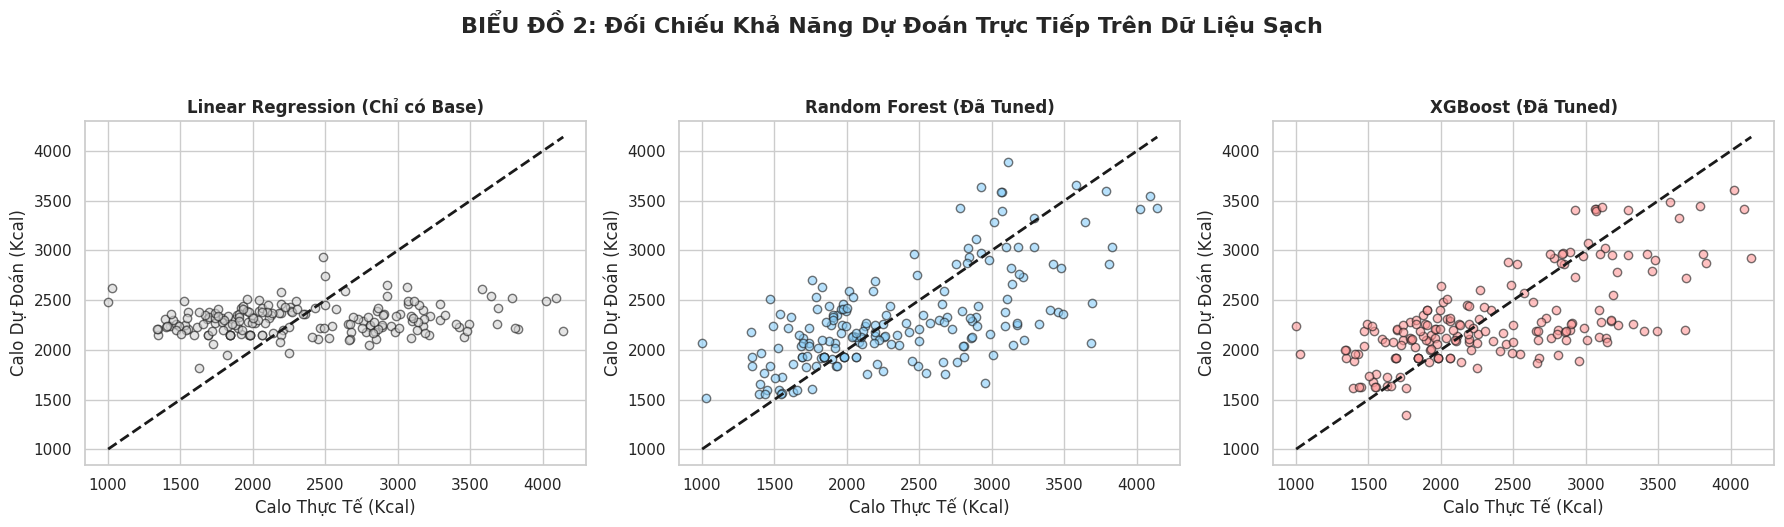

In [ ]:
# ==============================================================================
# BIỂU ĐỒ 2: THỰC TẾ VS DỰ ĐOÁN (SO SÁNH 3 MÔ HÌNH TRÊN DỮ LIỆU SẠCH)
# ==============================================================================
lr_model = get_model(baseline_models, 'Linear Regression')
rf_model = get_model(tuned_models, 'Random Forest')
xgb_model = get_model(tuned_models, 'XGBoost')

y_pred_lr = lr_model.predict(X_test_cl_scaled)
y_pred_rf = rf_model.predict(X_test_cl_scaled)
y_pred_xgb = xgb_model.predict(X_test_cl_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BIỂU ĐỒ 2: Đối Chiếu Khả Năng Dự Đoán Trực Tiếp Trên Dữ Liệu Sạch', fontsize=16, fontweight='bold', y=1.05)

# Ghi chú rõ trạng thái cuối cùng của từng thuật toán
models_preds = [('Linear Regression (Chỉ có Base)', y_pred_lr, '#D3D3D3'),
                ('Random Forest (Đã Tuned)', y_pred_rf, '#87CEFA'),
                ('XGBoost (Đã Tuned)', y_pred_xgb, '#FF9999')]

for i, (name, y_pred, color) in enumerate(models_preds):
    axes[i].scatter(y_test_cl, y_pred, alpha=0.6, color=color, edgecolor='k')
    min_val, max_val = min(y_test_cl.min(), y_pred.min()), max(y_test_cl.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Calo Thực Tế (Kcal)')
    axes[i].set_ylabel('Calo Dự Đoán (Kcal)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_REG_DIR, '02_actual_vs_predicted_strict.png'), dpi=300)
plt.show()

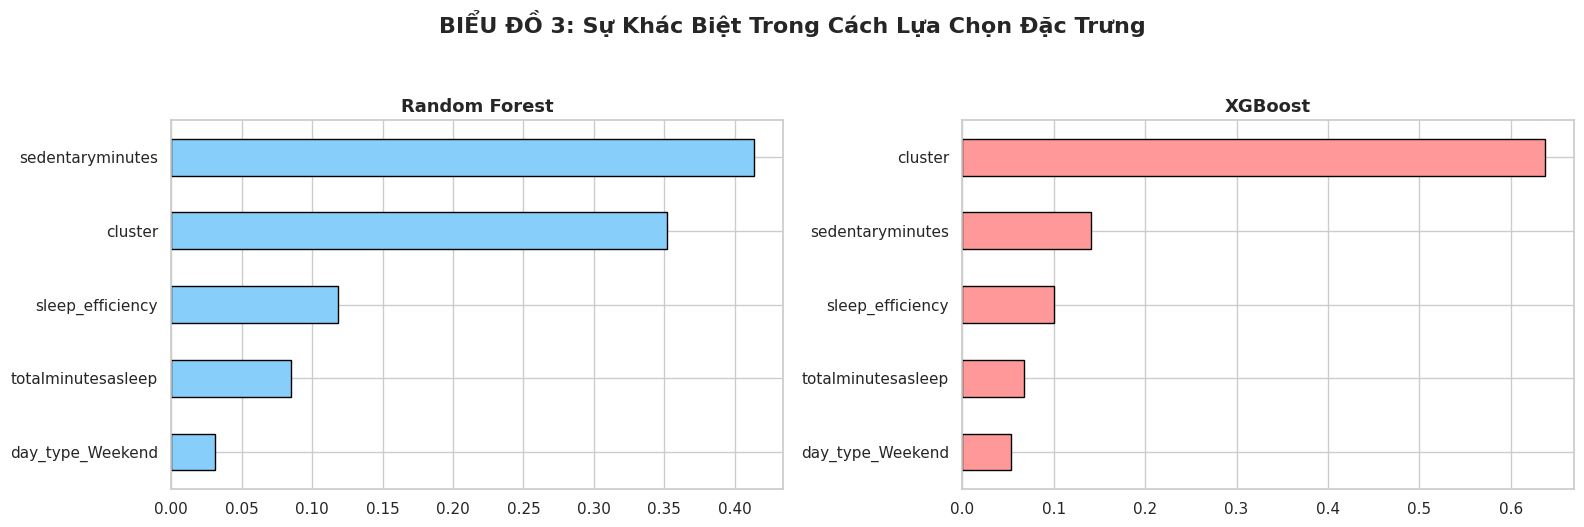

In [ ]:
# ==============================================================================
# BIỂU ĐỒ 3: TRỌNG SỐ ĐẶC TRƯNG (CHỈ ÁP DỤNG CHO RF VÀ XGB)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BIỂU ĐỒ 3: Sự Khác Biệt Trong Cách Lựa Chọn Đặc Trưng', fontsize=16, fontweight='bold', y=1.05)

rf_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
rf_importances.plot(kind='barh', ax=axes[0], color='#87CEFA', edgecolor='black')
axes[0].set_title('Random Forest', fontsize=13, fontweight='bold')

xgb_importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=True)
xgb_importances.plot(kind='barh', ax=axes[1], color='#FF9999', edgecolor='black')
axes[1].set_title('XGBoost', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_REG_DIR, '03_feature_importance.png'), dpi=300)
plt.show()





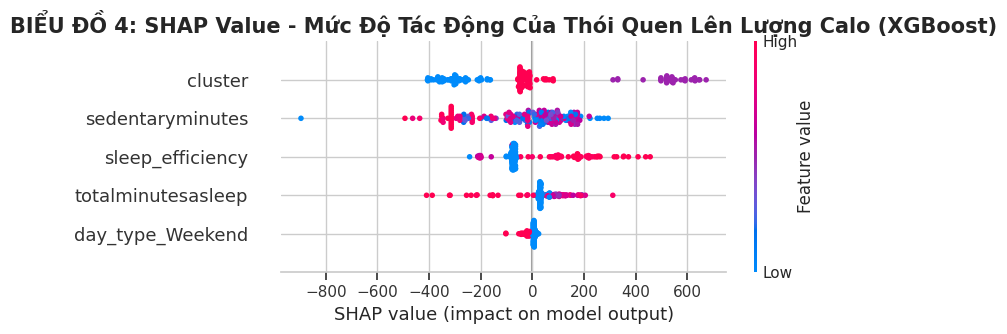

In [ ]:
# ==============================================================================
# BIỂU ĐỒ 4: GIẢI MÃ HỘP ĐEN SHAP CHO MÔ HÌNH VÔ ĐỊCH (XGBOOST)
# ==============================================================================
X_test_clean_df = pd.DataFrame(X_test_cl_scaled, columns=features)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_clean_df)

plt.figure(figsize=(12, 6))
plt.title("BIỂU ĐỒ 4: SHAP Value - Mức Độ Tác Động Của Thói Quen Lên Lượng Calo (XGBoost)", fontsize=15, fontweight='bold')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap.summary_plot(shap_values, X_test_clean_df, show=False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_REG_DIR, '04_shap_analysis.png'), dpi=300)
plt.show()


 ĐANG TẠO BẢNG ĐIỀU KHIỂN (DASHBOARD) TỔNG HỢP 4 KỊCH BẢN...
   [+] Đã lưu: /content/drive/MyDrive/Fitbit_Health_Analysis/reports/figures/05_regression/05_final_ablation_dashboard.png


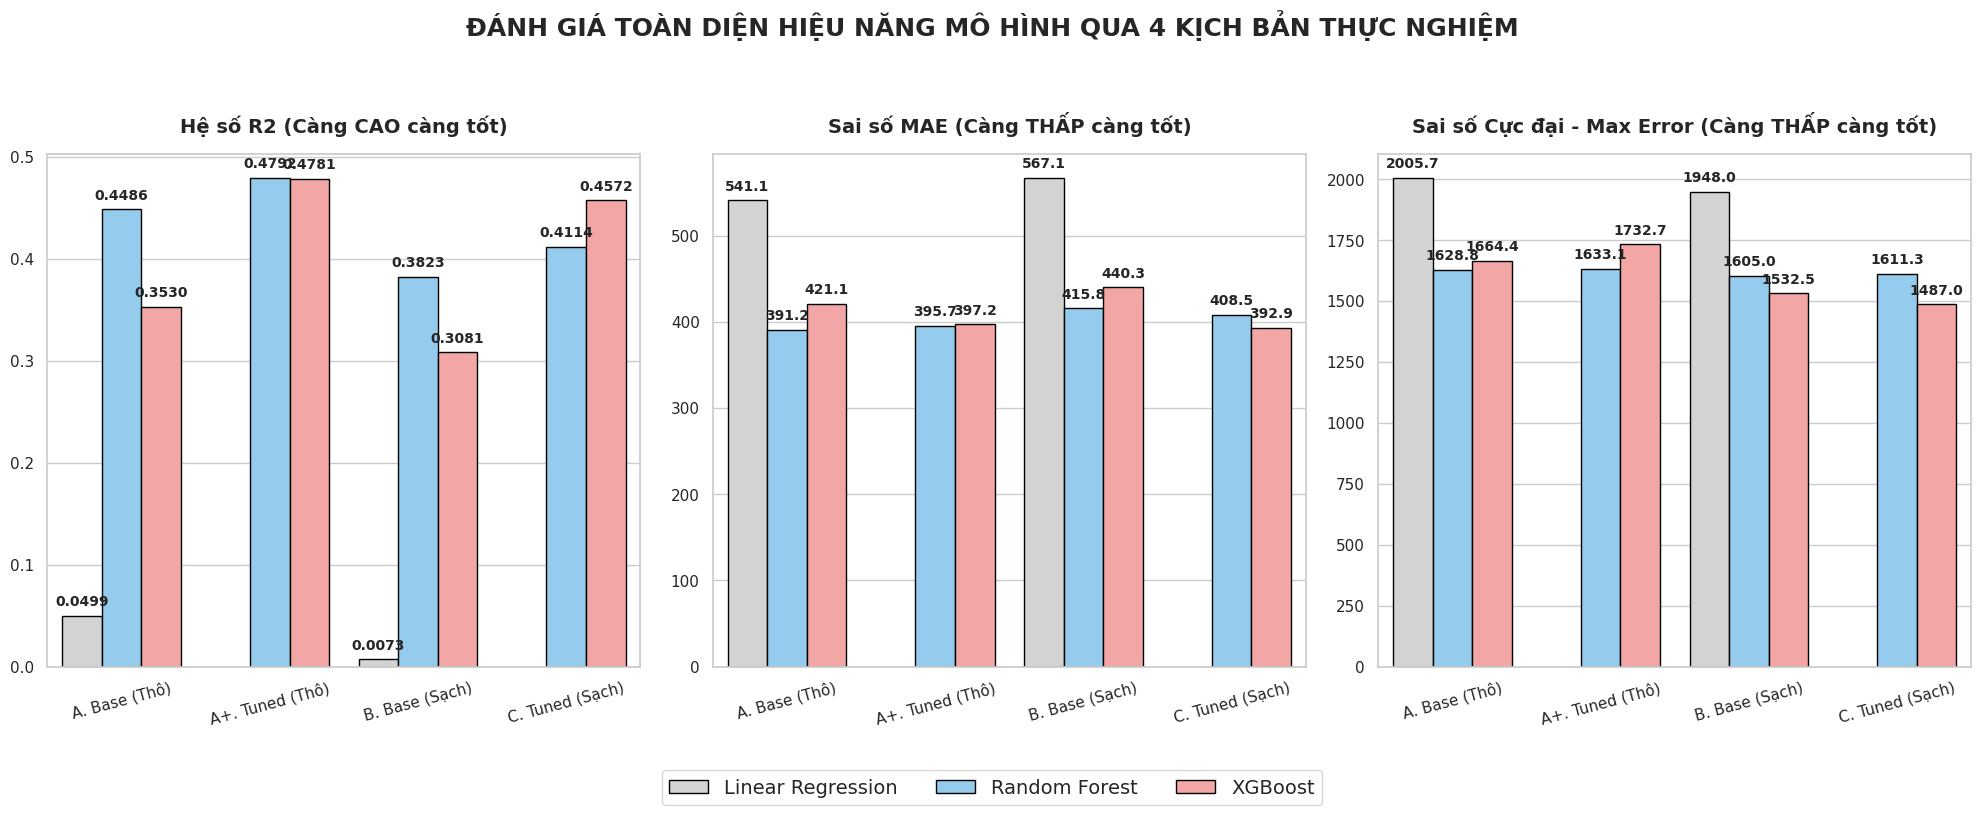

In [ ]:


print(" ĐANG TẠO BẢNG ĐIỀU KHIỂN (DASHBOARD) TỔNG HỢP 4 KỊCH BẢN...\n" + "="*60)

# Nhập chính xác bộ dữ liệu thực nghiệm của bạn
data = [
    # Kịch bản A (Base Thô)
    {'Kịch Bản': 'A. Base (Thô)', 'Mô Hình': 'Linear Regression', 'R2': 0.0499, 'MAE': 541.13, 'MaxError': 2005.69},
    {'Kịch Bản': 'A. Base (Thô)', 'Mô Hình': 'Random Forest', 'R2': 0.4486, 'MAE': 391.21, 'MaxError': 1628.84},
    {'Kịch Bản': 'A. Base (Thô)', 'Mô Hình': 'XGBoost', 'R2': 0.3530, 'MAE': 421.07, 'MaxError': 1664.36},

    # Kịch bản A+ (Tuned Thô) - Linear Regression không có
    {'Kịch Bản': 'A+. Tuned (Thô)', 'Mô Hình': 'Random Forest', 'R2': 0.4792, 'MAE': 395.74, 'MaxError': 1633.11},
    {'Kịch Bản': 'A+. Tuned (Thô)', 'Mô Hình': 'XGBoost', 'R2': 0.4781, 'MAE': 397.23, 'MaxError': 1732.71},

    # Kịch bản B (Base Sạch)
    {'Kịch Bản': 'B. Base (Sạch)', 'Mô Hình': 'Linear Regression', 'R2': 0.0073, 'MAE': 567.10, 'MaxError': 1947.99},
    {'Kịch Bản': 'B. Base (Sạch)', 'Mô Hình': 'Random Forest', 'R2': 0.3823, 'MAE': 415.84, 'MaxError': 1605.04},
    {'Kịch Bản': 'B. Base (Sạch)', 'Mô Hình': 'XGBoost', 'R2': 0.3081, 'MAE': 440.29, 'MaxError': 1532.45},

    # Kịch bản C (Tuned Sạch) - Linear Regression không có
    {'Kịch Bản': 'C. Tuned (Sạch)', 'Mô Hình': 'Random Forest', 'R2': 0.4114, 'MAE': 408.48, 'MaxError': 1611.31},
    {'Kịch Bản': 'C. Tuned (Sạch)', 'Mô Hình': 'XGBoost', 'R2': 0.4572, 'MAE': 392.85, 'MaxError': 1486.95},
]

df_metrics = pd.DataFrame(data)

# Cấu hình vẽ Dashboard 1 hàng 3 cột
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('ĐÁNH GIÁ TOÀN DIỆN HIỆU NĂNG MÔ HÌNH QUA 4 KỊCH BẢN THỰC NGHIỆM', fontsize=18, fontweight='bold', y=1.05)

palette = {'Linear Regression': '#D3D3D3', 'Random Forest': '#87CEFA', 'XGBoost': '#FF9999'}

# Cấu hình 3 biểu đồ
plots = [
    ('R2', 'Hệ số R2 (Càng CAO càng tốt)', axes[0], True),
    ('MAE', 'Sai số MAE (Càng THẤP càng tốt)', axes[1], False),
    ('MaxError', 'Sai số Cực đại - Max Error (Càng THẤP càng tốt)', axes[2], False)
]

for col, title, ax, is_higher_better in plots:
    sns.barplot(data=df_metrics, x='Kịch Bản', y=col, hue='Mô Hình', ax=ax, palette=palette, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=15)

    # Xóa legend ở từng ô nhỏ
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Gắn nhãn số liệu lên đầu cột
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f"{h:.4f}" if col == 'R2' else f"{h:.1f}",
                        (p.get_x() + p.get_width() / 2., h),
                        ha='center', va='bottom', fontsize=10, fontweight='bold',
                        xytext=(0, 5), textcoords='offset points')

# 3. Tạo Legend chung
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=14)

plt.tight_layout()

# 4. Lưu biểu đồ (Nếu bạn đã có thư mục FIG_REG_DIR)
try:
    plt.savefig('/content/drive/MyDrive/Fitbit_Health_Analysis/reports/figures/05_regression/05_final_ablation_dashboard.png', dpi=300, bbox_inches='tight')
    print("   [+] Đã lưu: /content/drive/MyDrive/Fitbit_Health_Analysis/reports/figures/05_regression/05_final_ablation_dashboard.png")
except:
    pass # Bỏ qua nếu đường dẫn không tồn tại trên môi trường hiện tại

plt.show()
